<a href="https://colab.research.google.com/github/zaporozhetsalena/My-first-project/blob/main/HW_11_1_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [129]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/hometasks/yulu_rental.csv')

In [107]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [130]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [131]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


In [132]:
df.shape

(10886, 19)

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10886 entries, 2011-01-01 00:00:00 to 2012-12-19 23:00:00
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       10886 non-null  int64  
 1   holiday      10886 non-null  int64  
 2   workingday   10886 non-null  int64  
 3   weather      10886 non-null  int64  
 4   temp         10886 non-null  float64
 5   atemp        10886 non-null  float64
 6   humidity     10886 non-null  int64  
 7   windspeed    10886 non-null  float64
 8   casual       10886 non-null  int64  
 9   registered   10886 non-null  int64  
 10  count        10886 non-null  int64  
 11  date         10886 non-null  object 
 12  day          10886 non-null  int32  
 13  week         10886 non-null  UInt32 
 14  weekday_num  10886 non-null  int32  
 15  weekday      10886 non-null  object 
 16  year         10886 non-null  int32  
 17  month        10886 non-null  int32  
 18  hour       

Кількість даних у наборі:
У датасеті міститься 10886 записів - рядки та 12 основних колонок(без урахування створених додаткових).
Рівень деталізації даних:
Дані мають погодинну деталізацію -кожен рядок відповідає одній годині конкретного дня.
Це видно з колонки datetime, яка включає дату і час (рік, місяць, день, година). Файл має об'єм 1.4+ MB

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


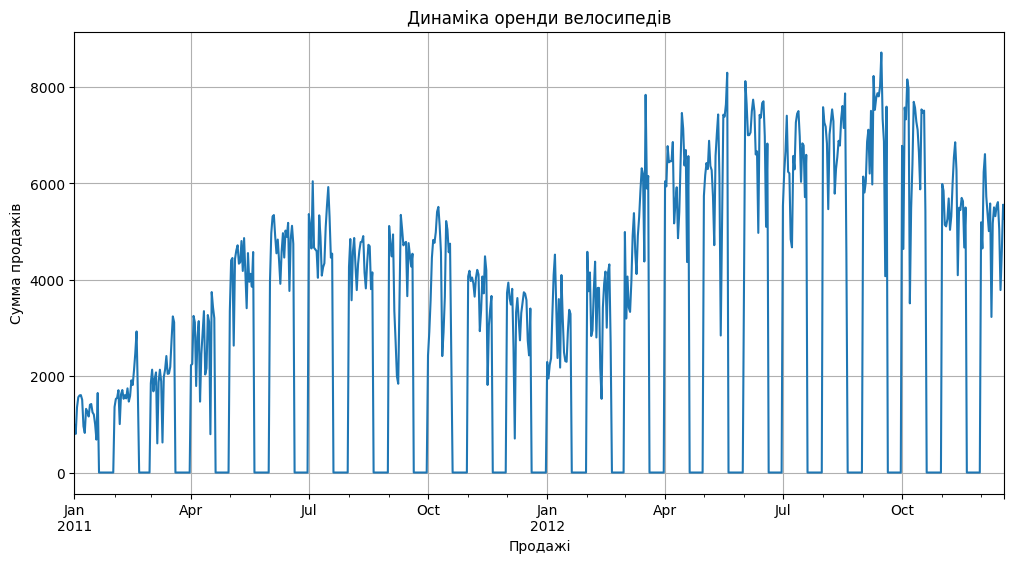

In [134]:
daily_rentals = df['count'].resample('D').sum()
daily_rentals.plot(
    kind="line",
    figsize=(12,6),
    title= "Динаміка оренди велосипедів",
    xlabel="Продажі",
    ylabel="Сумма продажів",
    grid=True
);

Графік має "заломи2 через пропущені значення, які при агрегації перетворюються в нулі. Загалом спостерігається зростання кількості оренд з часом. Помітна сезонність: в теплі періоди попит вищий. Аномалії можуть бути спричинені як погодними умовами, так і особливостями даних.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

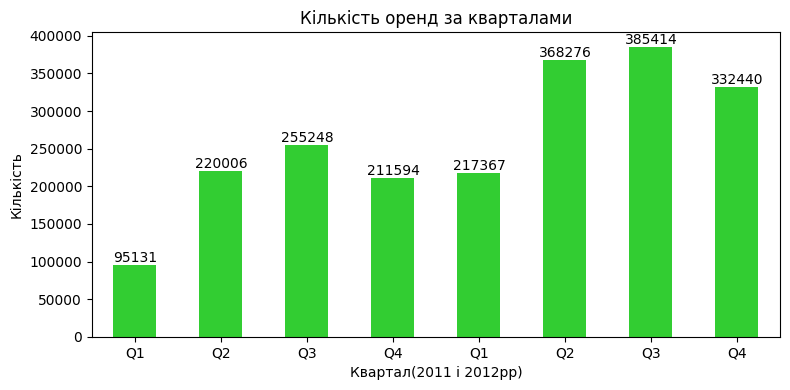

In [138]:
quarter_rentals = daily_rentals.resample('QE').sum()

# Назви кварталів
quarter_rentals.index = ["Q1", "Q2", "Q3", "Q4", "Q1", "Q2", "Q3", "Q4"]

ax = quarter_rentals.plot.bar(
    figsize=(8,4),
    color="limegreen",
    title="Кількість оренд за кварталами"
)

ax.set_xlabel("Квартал(2011 і 2012рр)")
ax.set_ylabel("Кількість")

for i, v in enumerate(quarter_rentals):
    ax.text(i, v, str(int(v)), ha='center', va='bottom')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



1/В який квартал найбільша середня кількість оренди велосипедів? Найбільш популярний квартал Q3–Q4 літо і осінь, особливо Q3/Q4 2012
2/Як ви можете пояснити таку сезонну закономірність?Тепла погода,частіше користуватись велосипедом для проїзду на роботу,тим самим зекономити кошти на пальне,якщо місто туристичне,то так зручніше подорожувати
3/У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми? Найпопулярніший квартал приблизно у 3.5–4 рази перевищує найменш популярний.Ділимо максимум поїздок на мінімум




## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [139]:
monthly_avg = df.groupby("month")["count"].mean()

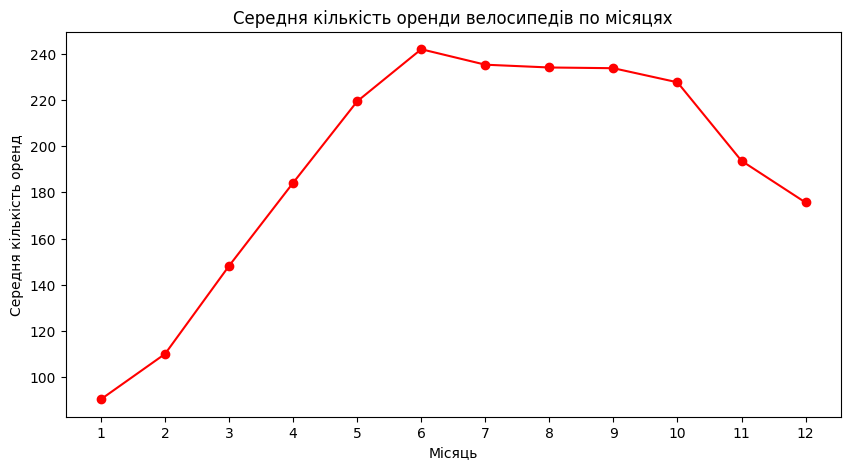

In [141]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    color="red",
    marker="o"
)

plt.xlabel("Місяць")
plt.ylabel("Середня кількість оренд")
plt.title("Середня кількість оренди велосипедів по місяцях")

plt.xticks(range(1, 13))

plt.show()

В які місяці спостерігається пік та спад оренди? З травня по вересень
Чи збігається ця закономірність з результатами з попереднього завдання? Так,показує одну тенденцію,тільки деталізованіше
Як може вплинути клімат на оренду велосипедів протягом року? Чим тепліший клімат на протязі року,тим вищий попит на аренду велосипедів

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

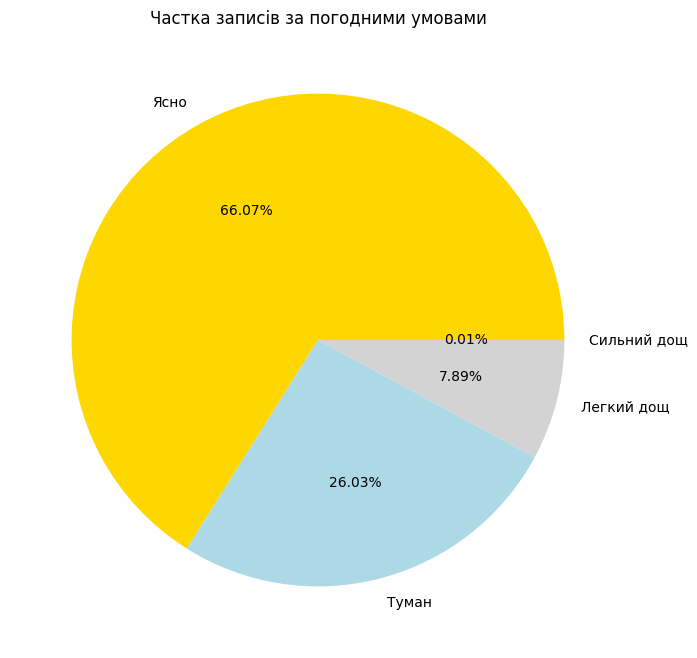

In [142]:
weather_counts = df["weather"].value_counts().sort_index()

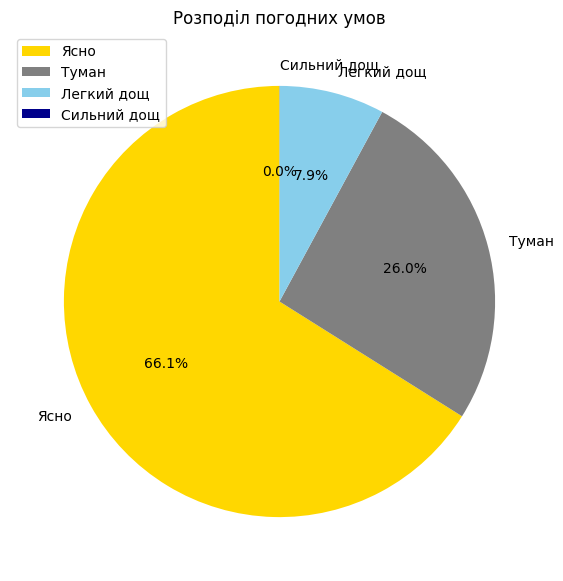

In [143]:
 labels = [
    "Ясно",
    "Туман",
    "Легкий дощ",
    "Сильний дощ"
]

colors = ["gold", "gray", "skyblue", "darkblue"]

plt.figure(figsize=(7,7))

plt.pie(
    weather_counts,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90
)

plt.title("Розподіл погодних умов")

plt.legend(labels, loc="best")

plt.show()

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

In [144]:
weather_map = {
    1: "Ясно",
    2: "Туман",
    3: "Легкий дощ",
    4: "Сильний дощ"
}
df["weather_name"] = df["weather"].map(weather_map)

<Figure size 1000x600 with 0 Axes>

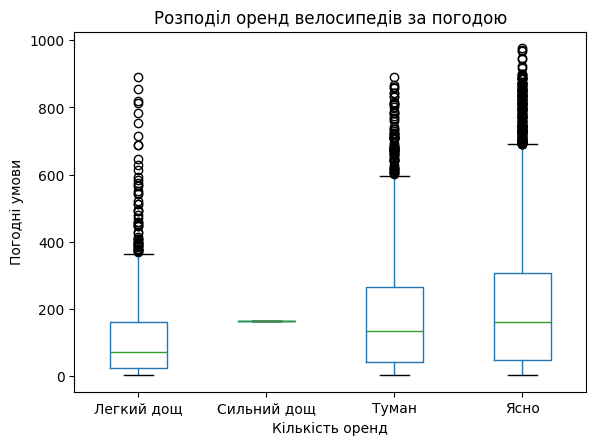

In [145]:
plt.figure(figsize=(10,6))
df.boxplot(
    column="count",
    by="weather_name",
    grid = False
)
plt.title("Розподіл оренд велосипедів за погодою")
plt.suptitle("")
plt.xlabel("Кількість оренд")
plt.ylabel("Погодні умови")
plt.show()

При якій погоді найбільший розкид у кількості оренди? -ясна погода
Чи є викиди outliers в даних? При якій погоді?-найчастіше багато високих викидів
При якій погоді медіанне значення оренди найвище?-ясноНайбільший розкид оренди спостерігається за ясної погоди, оскільки попит є високим, але змінним. Саме при ясній погоді також фіксується найбільша кількість викидів через пікові дні. Медіанне значення оренди є найвищим за ясної погоди, тоді як із погіршенням погодних умов воно поступово знижується

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

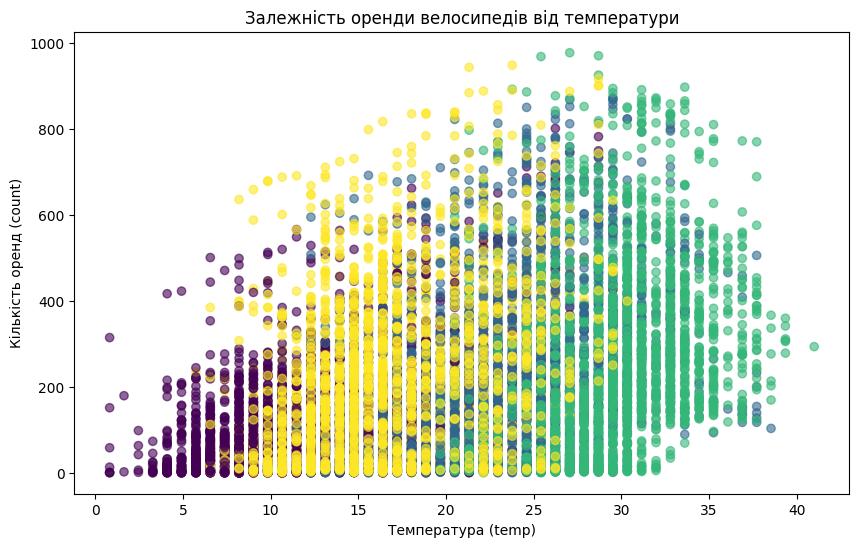

In [146]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df["temp"],
    df["count"],
    c=df["season"],
    alpha=0.6
)

plt.xlabel("Температура (temp)")
plt.ylabel("Кількість оренд (count)")
plt.title("Залежність оренди велосипедів від температури")
plt.show()

Існує чіткий позитивний зв’язок між температурою та кількістю оренд велосипедів: зі зростанням температури кількість оренд збільшується. Це пояснюється тим, що теплі погодні умови є більш комфортними для пересування на велосипеді, тоді як холодна погода знижує попит.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [166]:
df_grouped = df.groupby("weekday")[["casual", "registered"]].mean()

In [167]:
weekday_map = {
    1: "Пн",
    2: "Вт",
    3: "Ср",
    4: "Чт",
    5: "Пт",
    6: "Сб",
    7: "Нд"
}

<Figure size 1000x600 with 0 Axes>

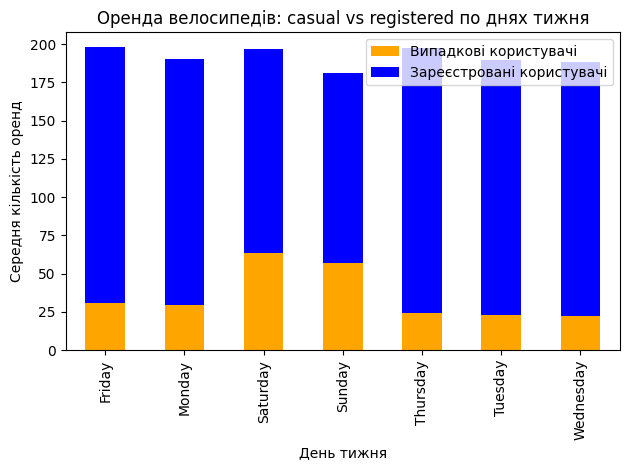

In [169]:
plt.figure(figsize=(10,6))

df_grouped[["casual", "registered"]].plot(
    kind="bar",
    stacked=True,
    color=["orange", "blue"]
)
plt.xlabel("День тижня")
plt.ylabel("Середня кількість оренд")
plt.title("Оренда велосипедів: casual vs registered по днях тижня")
plt.legend(["Випадкові користувачі", "Зареєстровані користувачі"])
plt.tight_layout()
plt.show()